### Nivel 1
##### 1.
Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el archivo se importa correctamente, con los nombres de columnas que le corresponden, sin manipular el archivo original.

Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.

Muestra las primeras 10 filas.

Adicionalmente, realiza un print donde compruebe que el DNI sólo tiene valores únicos.



In [12]:
import pandas as pd 

data = pd.read_excel(r"C:\Users\elisa\Documents\Data Analytics\Sprint 10\sprint10.xlsx", skiprows=3, index_col=0)
data_sorted = data.sort_values(by=["País d'origen", "Ciutat"])

if data_sorted["DNI"].is_unique:
    print("No hay DNI duplicados")
else:
    print("Hay DNI duplicados")

data_sorted.head(10)

No hay DNI duplicados


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


2.
Crea una columna que sea el nombre completo.

Crea una columna si la persona ha nacido en España o no.

Pone el DNI como índice del DataFrame (nombres de filas).

Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.

Sustituye a H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (enano/null/na).

Muestra todos los cambios que has realizado en una sola tabla.

In [13]:
data.insert(
    loc= data.columns.get_loc("Cognoms") + 1,
    column= "Nom Complet",
    value= data["Nom"] + " " + data["Cognoms"]
)

data.insert(
    loc= data.columns.get_loc("Ciutat") + 1,
    column= "Nascut a Espanya",
    value= data["País d'origen"].eq("Espanya").map({True:"Sí", False:"No"})
    )

data.set_index("DNI", inplace=True)

data = data.rename(columns={"Dia de Naixement": "Dia", "Mes de Naixement": "Mes", "Any de Naixement": "Any"})

data["Gènere"] = data["Gènere"].replace({"H": "Home", "D": "Dona", "A": "Altres"})

data["Gènere"] = data["Gènere"].fillna("NC")

In [14]:
data.head(5)

,Nom,Cognoms,Nom Complet,País d'origen,Ciutat,Nascut a Espanya,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Inês Ferreira Silva,Portugal,Lisboa,No,25,2,1953,Dona,1.144 €,NaN,1.0,Grup B
27724652S,Clara,Sánchez Martínez,Clara Sánchez Martínez,Espanya,Barcelona,Sí,18,3,1996,Dona,1.253 €,1.0,NaN,Grup A
38141675A,Fatima,Fassi,Fatima Fassi,Marroc,Rabat,No,6,11,2005,Altres,1.441 €,1.0,NaN,Grup A
59157262R,Khadija,Bennani Bennani,Khadija Bennani Bennani,Marroc,Rabat,No,20,1,1995,Dona,1.944 €,NaN,1.0,Grup B
69630528M,Toni,Sánchez García,Toni Sánchez García,Espanya,Barcelona,Sí,9,8,1999,Home,1.043 €,NaN,1.0,Grup A


3.
Junta las columnas Hijos y No Hijos en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema. La columna nueva debe llamarse "Hijos" y tomar los valores "Sí" o "No".

In [15]:
def fills_o_no(fila):
    if pd.notna(fila["Fills"]):
        return "Si" 
    else:
        return "No"
    
data["Fills"] = data.apply(fills_o_no, axis=1)

data = data.drop(columns="No Fills")

In [16]:
data.head(5)

,Nom,Cognoms,Nom Complet,País d'origen,Ciutat,Nascut a Espanya,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional
DNI,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Inês Ferreira Silva,Portugal,Lisboa,No,25,2,1953,Dona,1.144 €,No,Grup B
27724652S,Clara,Sánchez Martínez,Clara Sánchez Martínez,Espanya,Barcelona,Sí,18,3,1996,Dona,1.253 €,Si,Grup A
38141675A,Fatima,Fassi,Fatima Fassi,Marroc,Rabat,No,6,11,2005,Altres,1.441 €,Si,Grup A
59157262R,Khadija,Bennani Bennani,Khadija Bennani Bennani,Marroc,Rabat,No,20,1,1995,Dona,1.944 €,No,Grup B
69630528M,Toni,Sánchez García,Toni Sánchez García,Espanya,Barcelona,Sí,9,8,1999,Home,1.043 €,No,Grup A


4.
Crea una tabla resumen que permita ver el sueldo medio, mediano, mínimo y máximo por Género.

Ordena la tabla en función del sueldo medio.

In [17]:
data_salari = data.copy()
data_salari["Salari mensual"] = (
    data_salari["Salari mensual"]
    .astype(str)
    .str.replace("€", "")
    .str.replace(".", "")
    .str.strip()
    .astype(float)
    .fillna(0)
)

data_resumen_genere = data_salari.groupby("Gènere")["Salari mensual"].agg(
    Mitjana = "mean",
    Mediana = "median",
    Minimo = "min",
    Maximo = "max"
)

data_resumen_genere = data_resumen_genere.sort_values("Mitjana").style.format("{:.2f} €")

data_resumen_genere


,Mitjana,Mediana,Minimo,Maximo
Gènere,,,,
Dona,1469.44 €,1361.50 €,665.00 €,3021.00 €
NC,1568.87 €,1443.00 €,758.00 €,2969.00 €
Altres,1626.59 €,1545.00 €,703.00 €,3175.00 €
Home,1643.25 €,1531.00 €,737.00 €,3356.00 €


5.
Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).

Añade las medias a los márgenes de la tabla.

(EXTRA): Aplica formato condicional en la tabla para ver en un color más intenso los valores más elevados

In [18]:
data_salario_medio = data_salari.copy()
data_salario_medio = pd.pivot_table(
    data_salario_medio,
    values="Salari mensual",
    columns="País d'origen",
    index="Gènere",
    aggfunc="mean",
    margins=True,
    margins_name="Media Total"
)

data_salario_medio = data_salario_medio.style.background_gradient(cmap="Blues").format("{:.2f} €", na_rep= "-")
data_salario_medio

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Media Total
Gènere,,,,,,,,,,,
Altres,951.00 €,1141.00 €,1030.00 €,1706.18 €,-,1423.00 €,1365.00 €,1372.00 €,1765.00 €,1921.00 €,1626.59 €
Dona,1804.31 €,1291.80 €,1497.75 €,1460.16 €,1566.47 €,1247.18 €,1405.21 €,1517.80 €,1488.55 €,1489.46 €,1469.44 €
Home,2067.43 €,1583.29 €,1554.67 €,1682.11 €,1389.25 €,1672.88 €,1531.00 €,1625.00 €,1497.00 €,1162.56 €,1643.25 €
NC,1931.50 €,1135.67 €,1252.00 €,1597.14 €,1573.00 €,1316.00 €,1365.50 €,1583.00 €,1553.50 €,1758.00 €,1568.87 €
Media Total,1858.35 €,1431.68 €,1489.13 €,1582.16 €,1465.36 €,1421.17 €,1441.69 €,1559.08 €,1527.23 €,1448.33 €,1561.46 €


6.
Crea una nueva columna que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año. Utilizando esta columna crea una función que dada una fecha, te calcule la edad actual a día de hoy.

Utiliza la función que acabas de crear para generar una columna nueva en DataFrame con la edad actual.

In [19]:
import pandas as pd
from datetime import datetime, date, time, timedelta

data.insert(
    loc= data.columns.get_loc("Any") + 1,
    column= "Data de Naixement",
    value=pd.to_datetime({
        "day": data["Dia"],
        "month": data["Mes"],
        "year": data["Any"]
    })

)

def edat_avui(jorn):
    avui = datetime.now()
    edat = avui.year - jorn.year
    if (avui.month, avui.day) < (jorn.month, jorn.day):
        edat -= 1
    return edat

data.insert(
    loc=data.columns.get_loc("Data de Naixement") + 1,
    column= "Edat",
    value= data["Data de Naixement"].apply(edat_avui)
)

data["Data de Naixement"] = data["Data de Naixement"].dt.strftime("%d/%m/%Y")

In [20]:
data.head(3)

,Nom,Cognoms,Nom Complet,País d'origen,Ciutat,Nascut a Espanya,Dia,Mes,Any,Data de Naixement,Edat,Gènere,Salari mensual,Fills,Grup Professional
DNI,,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Inês Ferreira Silva,Portugal,Lisboa,No,25,2,1953,25/02/1953,73,Dona,1.144 €,No,Grup B
27724652S,Clara,Sánchez Martínez,Clara Sánchez Martínez,Espanya,Barcelona,Sí,18,3,1996,18/03/1996,30,Dona,1.253 €,Si,Grup A
38141675A,Fatima,Fassi,Fatima Fassi,Marroc,Rabat,No,6,11,2005,06/11/2005,20,Altres,1.441 €,Si,Grup A


#### Nivel 2
##### 1.
Utilizando el siguiente DataFrame, adjunta la columna "Incremento" al dataframe del nivel anterior.

Actualiza la columna salario en función de los porcentajes que se adjuntan. No modifiques manualmente los incrementos, escribe código Python para realizar las conversiones necesarias.

df_increment = pd.DataFrame({"Grupo":["Grupo A","Grupo B","Grupo C", "Grupo D" ] , "Incremento":

["5%","3,5%","2%","8%"]})

In [22]:
data_increment = pd.DataFrame({"Grupo":["Grupo A","Grupo B","Grupo C", "Grupo D" ] , "Incremento": ["5%","3,5%","2%","8%"]})

data_increment["Incremento"] = (
    data_increment["Incremento"]
    .astype(str)
    .str.replace(",", ".")
    .str.replace("%", "")
    .str.strip()
    .astype(float) / 100
)

data_increment["Grupo"] = data_increment["Grupo"].str.replace("Grupo", "Grup")
data["Grup Professional"] = data["Grup Professional"].str.strip()
data_increment["Grupo"] = data_increment["Grupo"].str.strip()

data_merge = data.merge(
    data_increment,
    left_on="Grup Professional",
    right_on="Grupo",
    how="left"
)

data_merge["Salari mensual"] = (
    data_merge["Salari mensual"]
    .astype(str)
    .str.replace(".", "")
    .str.replace("€", "")
    .str.strip()
)
data_merge["Salari mensual"] = pd.to_numeric(data_merge["Salari mensual"], errors= "coerce")

data_merge["Salari mensual"] = data_merge["Salari mensual"] * (1 + data_merge["Incremento"])

data_merge["Incremento_pct"] = (data_merge["Incremento"] * 100).round(1).astype(str).str.replace(".", ",") + "%"

data_merge.drop(columns=["Incremento", "Grupo"], inplace=True)

data_merge.head(5).style.format({"Salari mensual": "{:.2f} €"})

,Nom,Cognoms,Nom Complet,País d'origen,Ciutat,Nascut a Espanya,Dia,Mes,Any,Data de Naixement,Edat,Gènere,Salari mensual,Fills,Grup Professional,Incremento_pct
0,Inês,Ferreira Silva,Inês Ferreira Silva,Portugal,Lisboa,No,25,2,1953,25/02/1953,73,Dona,1184.04 €,No,Grup B,"3,5%"
1,Clara,Sánchez Martínez,Clara Sánchez Martínez,Espanya,Barcelona,Sí,18,3,1996,18/03/1996,30,Dona,1315.65 €,Si,Grup A,"5,0%"
2,Fatima,Fassi,Fatima Fassi,Marroc,Rabat,No,6,11,2005,06/11/2005,20,Altres,1513.05 €,Si,Grup A,"5,0%"
3,Khadija,Bennani Bennani,Khadija Bennani Bennani,Marroc,Rabat,No,20,1,1995,20/01/1995,31,Dona,2012.04 €,No,Grup B,"3,5%"
4,Toni,Sánchez García,Toni Sánchez García,Espanya,Barcelona,Sí,9,8,1999,09/08/1999,26,Home,1095.15 €,No,Grup A,"5,0%"


2.
Utilizando un bucle, exporta en 4 archivos (formato .xlsx o .csv) los datos de cada Grupo Profesional.

Por ejemplo: "datos_GrupA.xlsx" , "datos_GrupB.xlsx" ...

Exporta un 5º DataFrame en formato .xlsx o .csv que contenga cuántos trabajadores hay por cada Grupo Profesional, cuál es su sueldo medio y cuál es su edad media.

In [23]:
grups = data_merge["Grup Professional"].unique()

for grup in grups:
    data_grups = data_merge[data_merge["Grup Professional"] == grup]
    data_grups.to_csv(f"datos_{grup.replace(" ", "")}.csv", index=False)

data_resum = data_merge.groupby("Grup Professional").agg(
    Treballadors = ("Grup Professional", "count"),
    Sou_mig = ("Salari mensual", "mean"),
    Edat_mitjana = ("Edat", "mean")
)

data_resum = data_resum.round(2).reset_index()
data_resum.to_csv(f"resumen_datos.csv", index=False)
data_resum.head(10)


,Grup Professional,Treballadors,Sou_mig,Edat_mitjana
0,Grup A,490,1213.32,49.28
1,Grup B,318,1724.55,48.02
2,Grup C,137,2289.19,51.07
3,Grup D,55,3100.82,45.18


#### Nivel 3
El nivel 3 de este sprint es totalmente diferente a otros sprints que has hecho hasta ahora, ya que son ejercicios más abstractos que requieren pelearse bastante. No siguen con el mismo dataset de los niveles anteriores, sino que te plantean dos situaciones nuevas totalmente distintas entre sí.

1.
Crea una función que tome un dataframe como parámetro de entrada.

La función debe crear (y exportar) un gráfico automáticamente para cada columna del dataframe. Por ejemplo:

un histograma/boxplot si la variable es numérica
unas barras de los valores más frecuentes si es categórica
unas barras de los años más frecuentes si el dato está en formato fecha.
La idea es crear una función que funcione por cualquier dataframe, no sólo con lo que hemos trabajado hasta ahora.

Muestra el resultado de la función en alguno de los datasets de ejemplo que contiene el paquete seaborn. Por ejemplo, iris , penguins o titanic .

Ten en consideración que en el siguiente sprint trabajarás exclusivamente con gráficos. El objetivo de este ejercicio no es crear gráficos muy elaborados, sino resolver una necesidad de forma rápida y automática.

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool

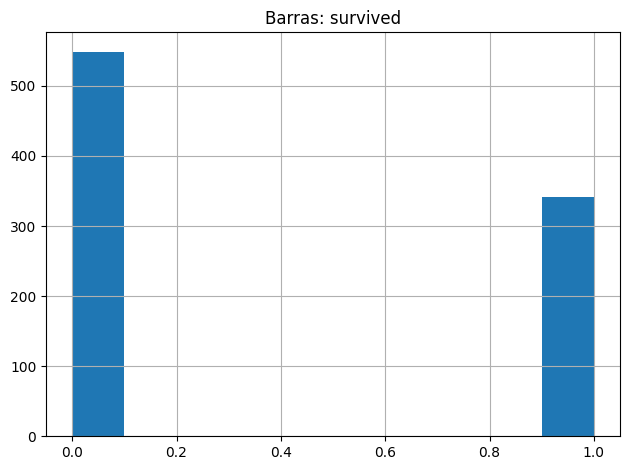

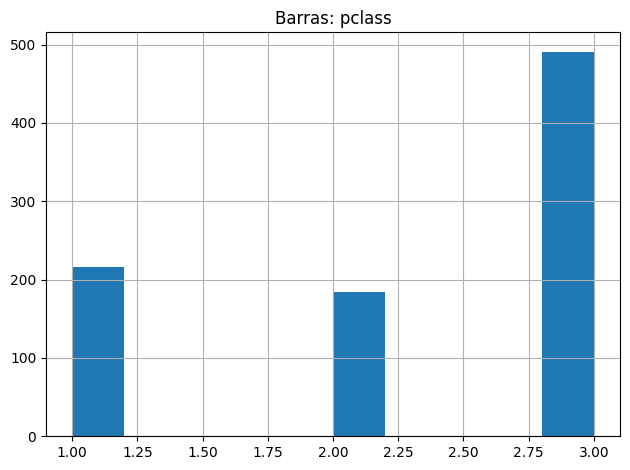

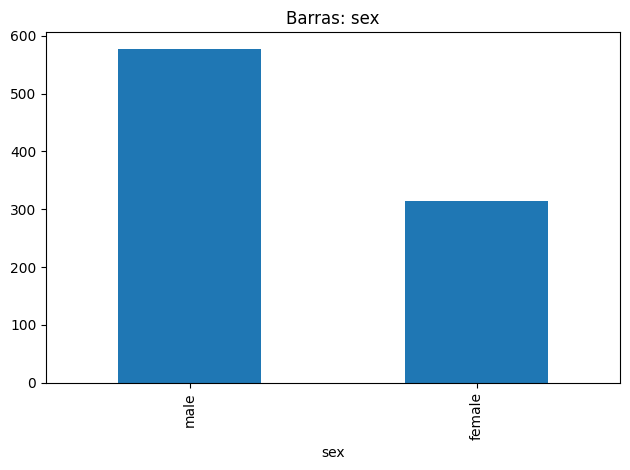

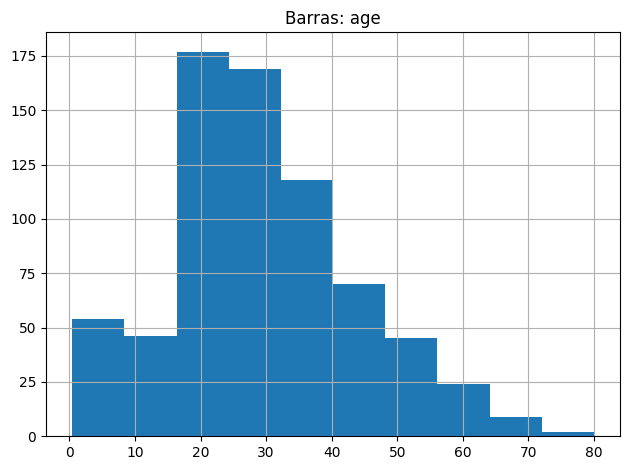

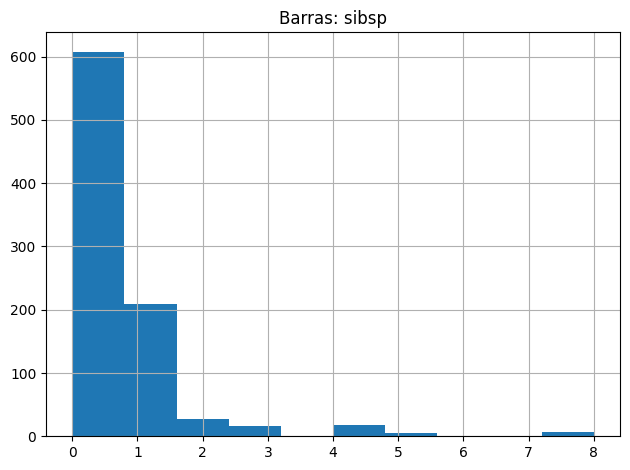

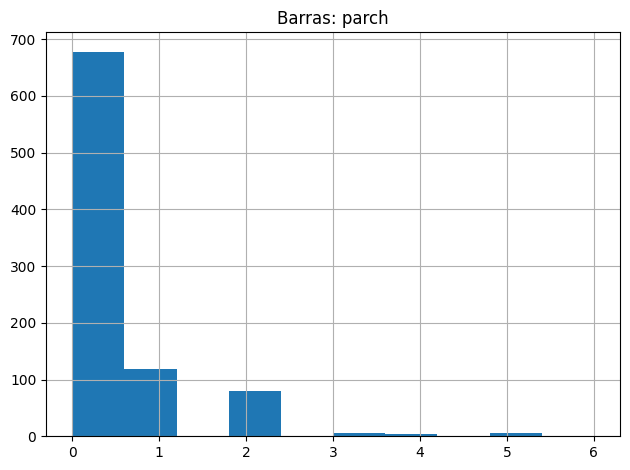

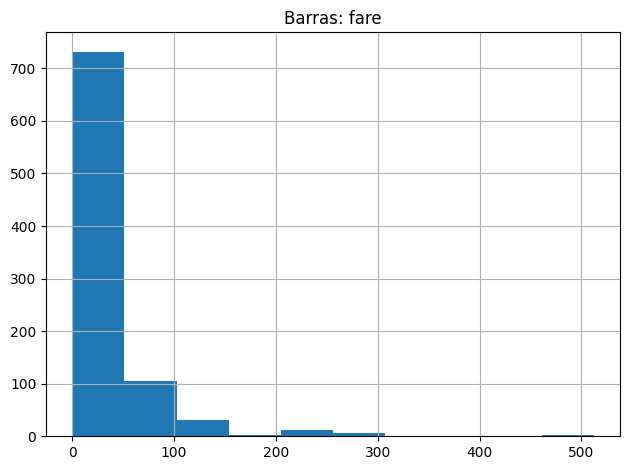

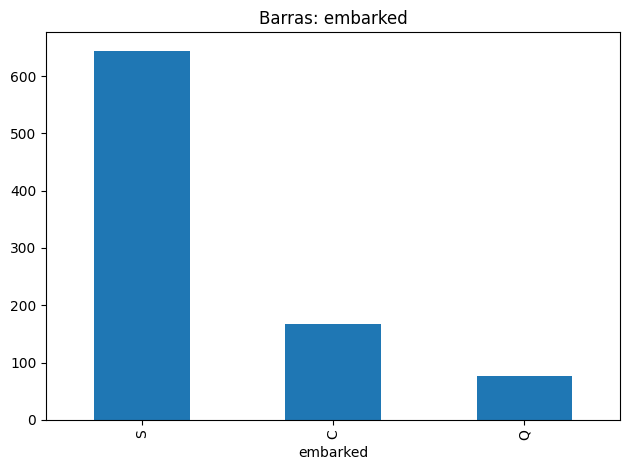

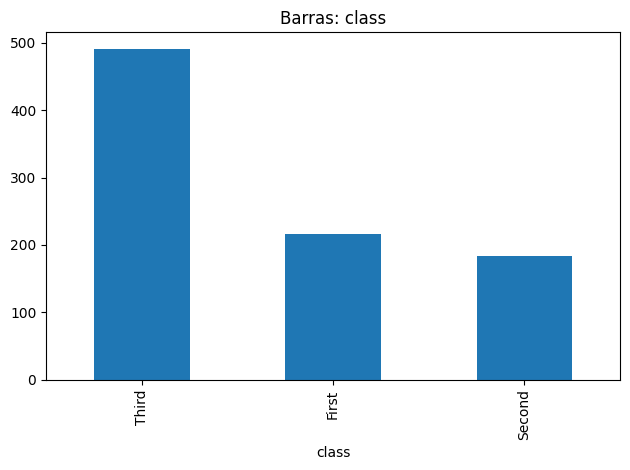

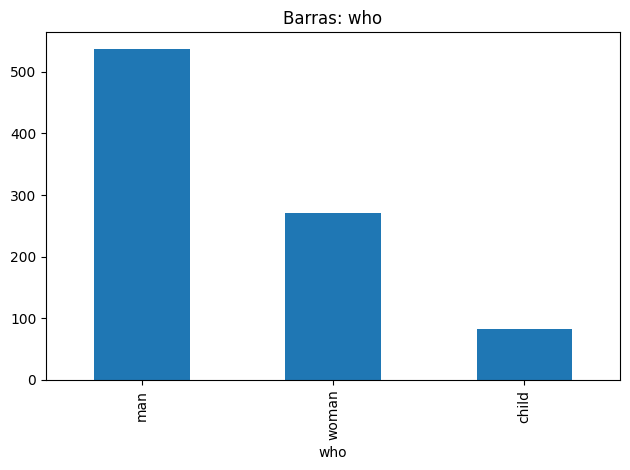

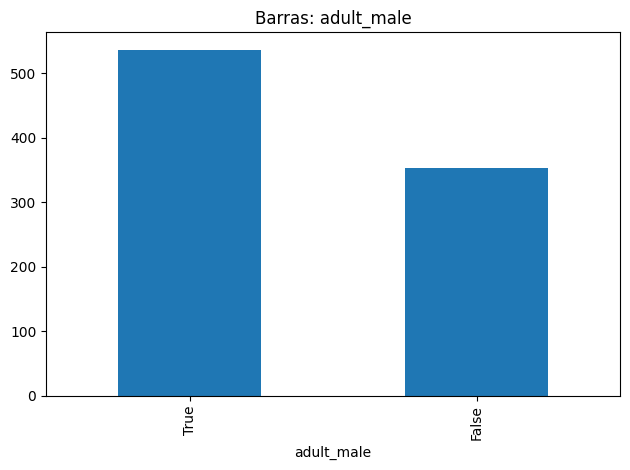

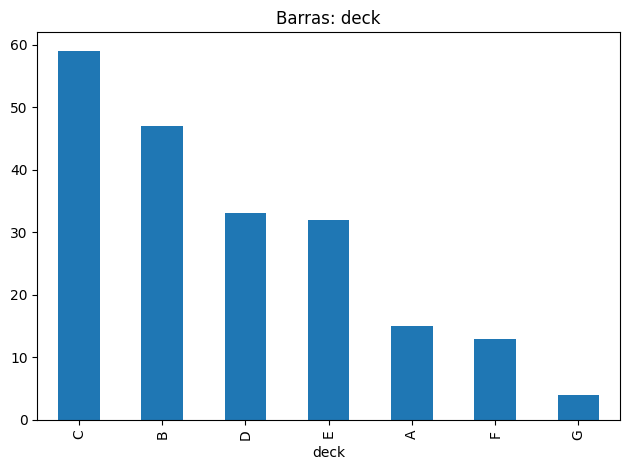

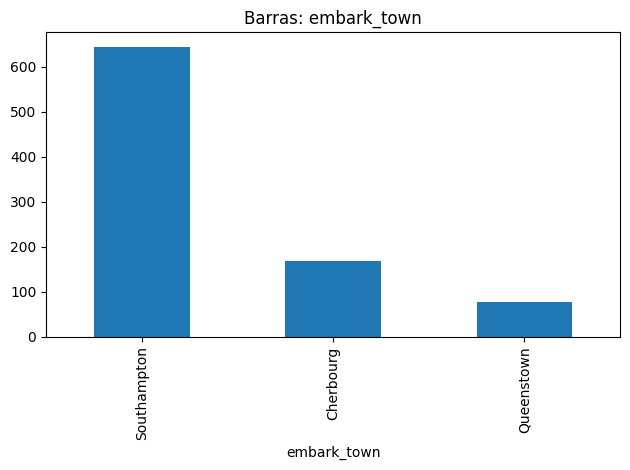

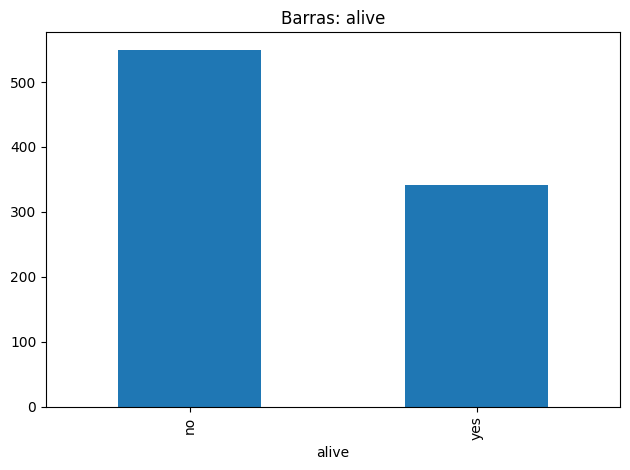

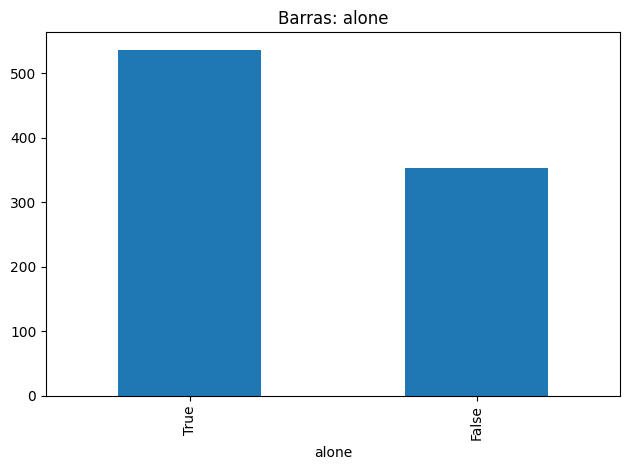

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datos = sns.load_dataset("titanic")

def grafico_automatico(df):
    for columna in df.columns:
        plt.figure()

        if df[columna].dtype in ["int64", "float64"]:
            df[columna].hist()
            plt.title(f"Barras: {columna}")

        elif df[columna].dtype.name in ["object", "str", "bool", "category"]:
            df[columna].value_counts().head(10).plot(kind="bar")
            plt.title(f"Barras: {columna}")

        elif df[columna].dtype == "datetime64[ns]":
            df[columna].dt.year.value_counts().sort_index().plot(kind="bar")
            plt.title(f"Barras: {columna}")

        plt.tight_layout()
        plt.savefig(f"Grafico_{columna}.png")
        plt.show()

grafico_automatico(datos)   


In [23]:
datos.dtypes

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

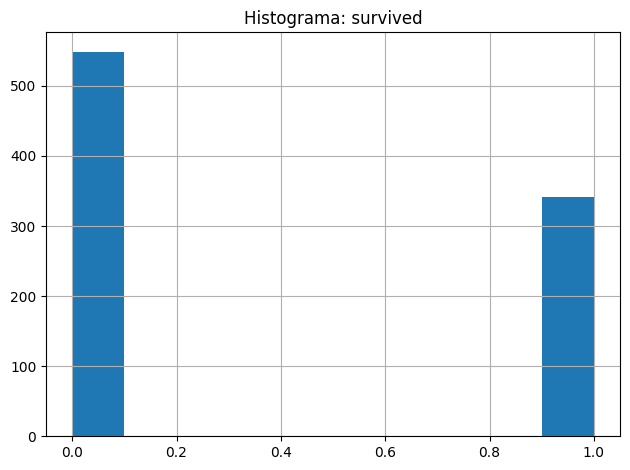

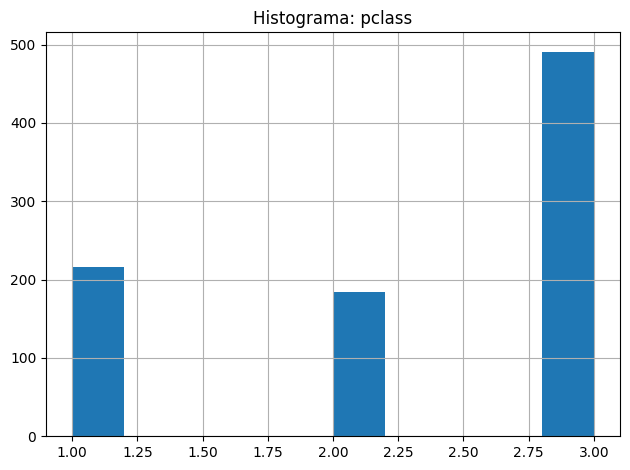

<Figure size 640x480 with 0 Axes>

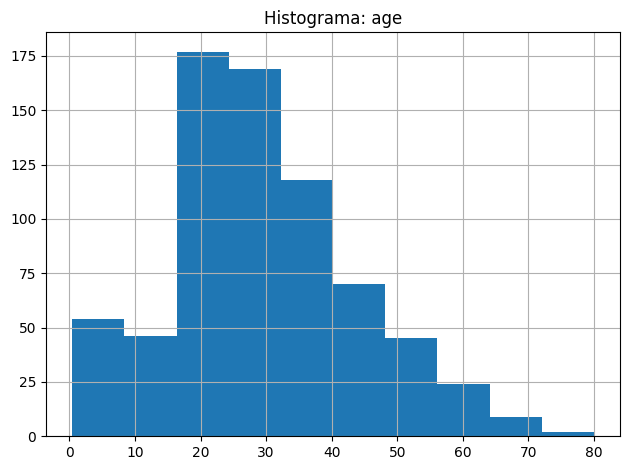

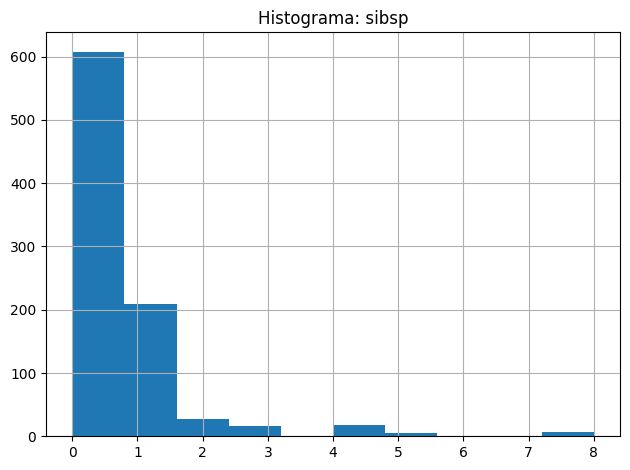

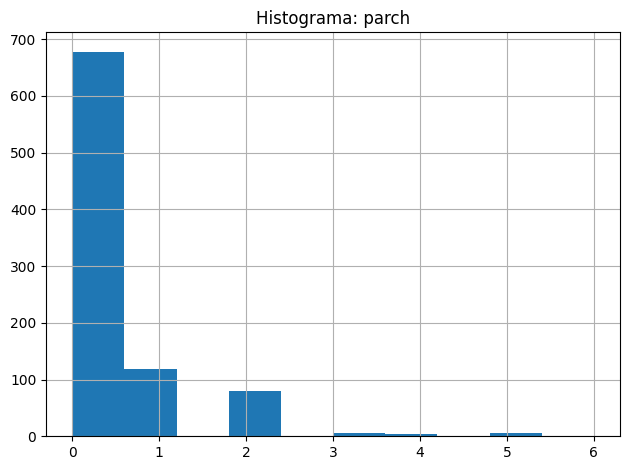

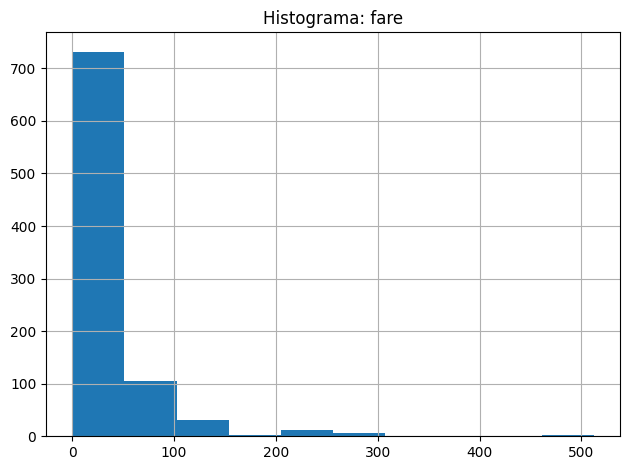

<Figure size 640x480 with 0 Axes>

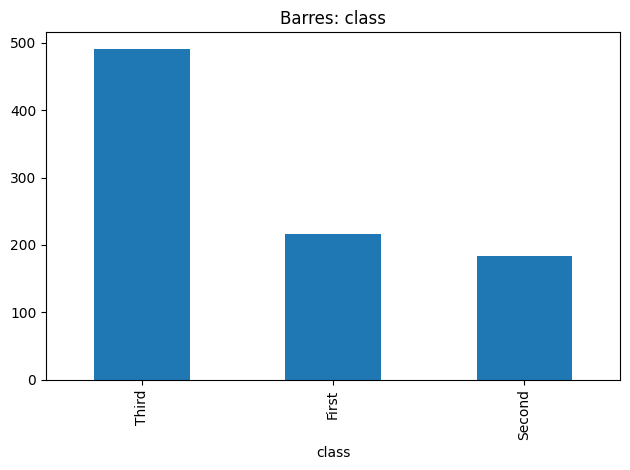

<Figure size 640x480 with 0 Axes>

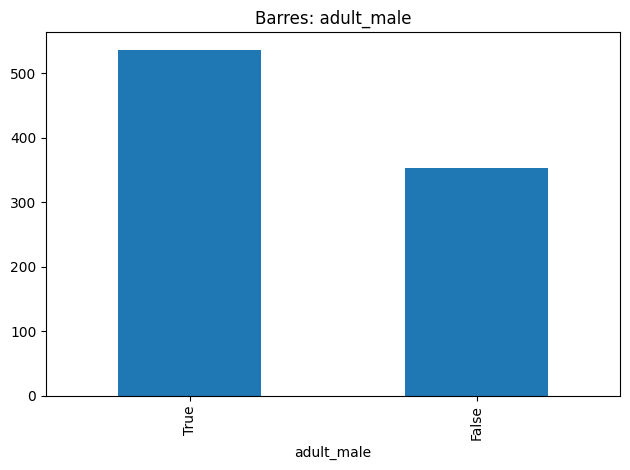

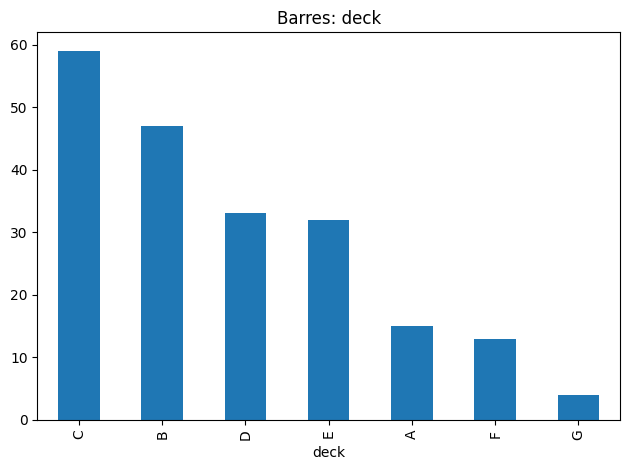

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

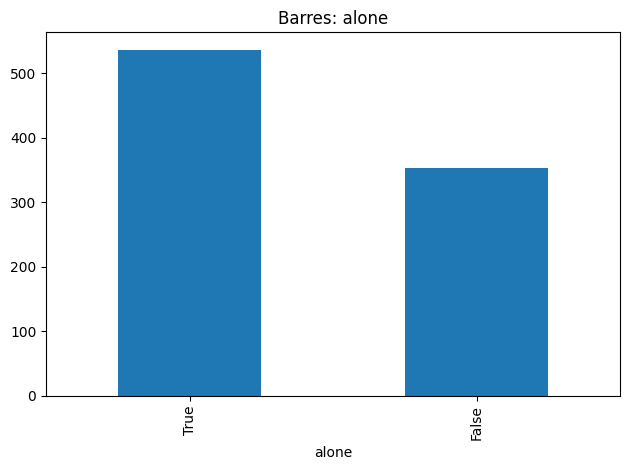

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

df = sns.load_dataset("titanic")

def graficos_automaticos(df):
    for columna in df.columns:
        plt.figure()

        if df[columna].dtype in ["int64", "float64"]:
            df[columna].hist()
            plt.title(f"Histograma_{columna}")

        elif df[columna].dtype == "object" or df[columna].dtype == "bool" or df[columna].dtype.name == "category":   
            df[columna].value_counts().head(10).plot(kind="bar")
            plt.title(f"Barres_{columna}")

        elif df[columna].dtype == "datetime64[ns]":
            df[columna].dt.year.value_counts().sort_index().plot(kind="bar")
            plt.title(f"Anys_{columna}")

        plt.tight_layout()
        plt.savefig(f"Grafico_{columna}.png")
        plt.show()

graficos_automaticos(df)
